### Build a DNN using Keras with `RELU` and `ADAM`

#### Load tensorflow

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
import tensorflow as tf
import keras
import numpy as np
print(tf.__version__)
tf.random.set_seed(42)

2.0.0-beta1


Using TensorFlow backend.


#### Collect Fashion mnist data from tf.keras.datasets 

In [3]:
(trainX, trainY), (testX, testY) = keras.datasets.fashion_mnist.load_data()
print(testY[0:5])

[9 2 1 1 6]


#### Change train and test labels into one-hot vectors

In [4]:
np.unique(trainY)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [5]:
testY = tf.keras.utils.to_categorical(testY, num_classes=len(np.unique(testY)))
trainY = tf.keras.utils.to_categorical(trainY, num_classes=len(np.unique(trainY)))

In [6]:
np.unique(trainY)

array([0., 1.], dtype=float32)

### Visualize the data

Plot first 10 images in the triaining set and their labels.

In [7]:
trainX.shape

(60000, 28, 28)

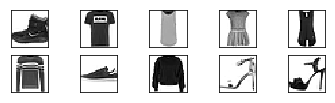

label for each of the above image: [9, 0, 0, 3, 0, 2, 7, 2, 5, 5]


In [8]:
import matplotlib.pyplot as plt
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 
labels = []
#plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(trainX[i], cmap=plt.cm.binary)
    labels.append(np.where(trainY[i] == 1)[0][0])
plt.show()
print("label for each of the above image:", labels)

#### Build the Graph

#### Initialize model, reshape & normalize data

In [9]:
#Initialize Sequential model
model = tf.keras.models.Sequential()

#Reshape data from 2D to 1D -> 28x28 to 784
model.add(tf.keras.layers.Reshape((784,),input_shape=(28,28,)))

#Normalize the data
model.add(tf.keras.layers.BatchNormalization())

#### Add two fully connected layers with 200 and 100 neurons respectively with `relu` activations. Add a dropout layer with `p=0.25`

In [10]:
#Add Dense Layer with 200 neurons
model.add(tf.keras.layers.Dense(200, activation='relu'))

#Add Dense Layer with 100 neurons
model.add(tf.keras.layers.Dense(100, activation='relu'))

#Add dropout layer
model.add(tf.keras.layers.Dropout(rate=0.25))

### Add the output layer with a fully connected layer with 10 neurons with `softmax` activation. Use `categorical_crossentropy` loss and `adam` optimizer and train the network. And, report the final validation.

In [11]:
#Add output Layer with 10 neurons
model.add(tf.keras.layers.Dense(10, activation='softmax'))

In [12]:
#Comile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [13]:
#Review the model summary
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape (Reshape)            (None, 784)               0         
_________________________________________________________________
batch_normalization (BatchNo (None, 784)               3136      
_________________________________________________________________
dense (Dense)                (None, 200)               157000    
_________________________________________________________________
dense_1 (Dense)              (None, 100)               20100     
_________________________________________________________________
dropout (Dropout)            (None, 100)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
Total params: 181,246
Trainable params: 179,678
Non-trainable params: 1,568
______________________________________________

In [14]:
model.fit(trainX, trainY, 
          validation_data=(testX, testY), 
          epochs=10,
          batch_size=32)

W0824 21:26:23.926647 139734254475072 deprecation.py:323] From /home/siju/.local/lib/python3.6/site-packages/tensorflow/python/ops/math_grad.py:1250: add_dispatch_support.<locals>.wrapper (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 3s 53us/sample - loss: 0.5065 - accuracy: 0.8191 - val_loss: 0.3981 - val_accuracy: 0.8568
Epoch 2/10
60000/60000 [==============================] - 3s 53us/sample - loss: 0.3949 - accuracy: 0.8563 - val_loss: 0.3704 - val_accuracy: 0.8666
Epoch 3/10
60000/60000 [==============================] - 3s 52us/sample - loss: 0.3601 - accuracy: 0.8675 - val_loss: 0.3681 - val_accuracy: 0.8676
Epoch 4/10
60000/60000 [==============================] - 3s 53us/sample - loss: 0.3354 - accuracy: 0.8769 - val_loss: 0.3546 - val_accuracy: 0.8736
Epoch 5/10
60000/60000 [==============================] - 3s 50us/sample - loss: 0.3148 - accuracy: 0.8839 - val_loss: 0.3409 - val_accuracy: 0.8759
Epoch 6/10
60000/60000 [==============================] - 3s 50us/sample - loss: 0.2991 - accuracy: 0.8873 - val_loss: 0.3602 - val_accuracy: 0.8742
Epoch 7/10
60000/60000 [==============================] 

### Results

The validation accuracy is 88% with 10 epochs and batch size of 32